In [2]:
!pip install kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"achusn","key":"c2ec5c66361f8a64d647aecdeed761d3"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d agrigorev/clothing-dataset-full

Dataset URL: https://www.kaggle.com/datasets/agrigorev/clothing-dataset-full
License(s): CC0-1.0
100% 6.50G/6.50G [01:09<00:00, 101MB/s] 



In [6]:
!unzip agrigorev/clothing-dataset-full

unzip:  cannot find or open agrigorev/clothing-dataset-full, agrigorev/clothing-dataset-full.zip or agrigorev/clothing-dataset-full.ZIP.


In [7]:
!unzip clothing-dataset-full.zip

Streaming output truncated to the last 5000 lines.
  inflating: images_original/2126322b-b4eb-4410-988a-9261155c017a.jpg  
  inflating: images_original/2135ff47-f57e-4252-8fb8-5f89f1f757c4.jpg  
  inflating: images_original/214245bb-8308-4981-be30-4f82e4766607.jpg  
  inflating: images_original/2153199f-0a48-4334-bb12-51e07486b5c0.jpg  
  inflating: images_original/21531a69-d7f0-4d77-a2d9-a4269652344e.jpg  
  inflating: images_original/215d49b8-c7b7-4ce0-979c-9f9edf1065d7.jpg  
  inflating: images_original/2160a577-406a-4812-ada2-2a3cb30c2ba8.jpg  
  inflating: images_original/216ddb53-2a80-4218-99b0-b5b721744fc3.jpg  
  inflating: images_original/216f2433-a511-4834-9b8c-d01bc926d5d4.jpg  
  inflating: images_original/2174d585-e8cf-43ce-bb61-de1567c74fd5.jpg  
  inflating: images_original/21845140-b1e3-4344-b836-60e1d4b09311.jpg  
  inflating: images_original/2199f7e3-4474-4ebc-aeff-4da50d2e49d5.jpg  
  inflating: images_original/21a06a8f-583d-40c5-b5f8-2b735af0f8e5.jpg  
  inflating: 

In [8]:
import pandas as pd

df = pd.read_csv('/content/images.csv')
df.head()

,image,sender_id,label,kids
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False


In [9]:
df.columns

Index(['image', 'sender_id', 'label', 'kids'], dtype='object')

In [10]:
df['label'].value_counts()

,count
label,
T-Shirt,1011
Longsleeve,699
Pants,692
Shoes,431
Shirt,378
Dress,357
Outwear,312
Shorts,308
Not sure,228


In [11]:
# cleaning

labels_to_remove = ['Skip', 'Not sure', 'Other', 'Blouse','Top','Body']
df = df[~df['label'].isin(labels_to_remove)]


In [12]:
df['label'].value_counts()

,count
label,
T-Shirt,1011
Longsleeve,699
Pants,692
Shoes,431
Shirt,378
Dress,357
Outwear,312
Shorts,308
Hat,171


In [13]:
# Create image path
df['image_path'] = df['image'].apply(lambda x: f"/content/images_original/{x}.jpg")

In [14]:
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 128

images = []
labels = []

# Shuffling dataframe to avoid bias
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

for _, row in tqdm(df_shuffled.iterrows(), total=len(df_shuffled)):
    img_path = row['image_path']
    label = row['label']

    img = cv2.imread(img_path)

    # Skipping corrupted/missing images
    if img is None:
        continue

    try:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(label)

    except:
        continue

print("Total images loaded:", len(images))

100%|██████████| 4961/4961 [04:37<00:00, 17.86it/s]

Total images loaded: 4961


In [15]:
import os

len(os.listdir('/content/images_original'))

5762

In [16]:
import numpy as np

X = np.array(images)
y = np.array(labels)

# Normalize
X = X / 255.0

print(X.shape)
print(len(y))

(4961, 128, 128, 3)
4961


In [17]:
X

array([[[[0.05490196, 0.05882353, 0.09803922],
         [0.04313725, 0.05098039, 0.0745098 ],
         [0.04313725, 0.05098039, 0.08627451],
         ...,
         [0.37254902, 0.39215686, 0.40392157],
         [0.29411765, 0.31372549, 0.33333333],
         [0.32156863, 0.33333333, 0.36078431]],

        [[0.05882353, 0.0627451 , 0.07843137],
         [0.03529412, 0.04313725, 0.0745098 ],
         [0.03921569, 0.04705882, 0.07843137],
         ...,
         [0.33333333, 0.35294118, 0.35686275],
         [0.31372549, 0.34509804, 0.34509804],
         [0.32156863, 0.34117647, 0.34509804]],

        [[0.02745098, 0.01960784, 0.04313725],
         [0.01568627, 0.01960784, 0.03529412],
         [0.02352941, 0.02352941, 0.04705882],
         ...,
         [0.35686275, 0.38823529, 0.38823529],
         [0.35294118, 0.37254902, 0.37647059],
         [0.34509804, 0.36470588, 0.36862745]],

        ...,

        [[0.54117647, 0.55686275, 0.56078431],
         [0.53333333, 0.55294118, 0.55686275]

In [18]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot encoding
y_categorical = to_categorical(y_encoded)

print("Classes:", le.classes_)

Classes: ['Blazer' 'Dress' 'Hat' 'Hoodie' 'Longsleeve' 'Outwear' 'Pants' 'Polo'
 'Shirt' 'Shoes' 'Shorts' 'Skirt' 'T-Shirt' 'Undershirt']


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3968, 128, 128, 3)
Test: (993, 128, 128, 3)


In [20]:
# model from scratch

from tensorflow.keras import layers, models

model1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(le.classes_), activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.1988 - loss: 2.4302 - val_accuracy: 0.2280 - val_loss: 2.3416
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3463 - loss: 2.1086 - val_accuracy: 0.4106 - val_loss: 1.8810
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4436 - loss: 1.8004 - val_accuracy: 0.5214 - val_loss: 1.6117
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4877 - loss: 1.6142 - val_accuracy: 0.5605 - val_loss: 1.5281
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5476 - loss: 1.4369 - val_accuracy: 0.5668 - val_loss: 1.4433
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5898 - loss: 1.2814 - val_accuracy: 0.5856 - val_loss: 1.3629
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6320 - loss: 1.1180 - val_accuracy: 0.6159 - val_loss: 1.3435
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6692 - loss: 0.9950 - val_acc

In [21]:
# Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

history_aug = model1.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test)
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.4758 - loss: 1.7345 - val_accuracy: 0.6344 - val_loss: 1.2098
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.5557 - loss: 1.4734 - val_accuracy: 0.6465 - val_loss: 1.2112
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step - accuracy: 0.5711 - loss: 1.4081 - val_accuracy: 0.6788 - val_loss: 1.0550
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.5784 - loss: 1.3511 - val_accuracy: 0.6727 - val_loss: 1.0328
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.5910 - loss: 1.2999 - val_accuracy: 0.6767 - val_loss: 1.0220
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.6018 - loss: 1.2556 - val_accuracy: 0.6838 - val_loss: 1.0235
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.6159 - loss: 1.2118 - val_accuracy: 0.6838 - val_loss: 1.0138
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.6164 - loss: 1

In [22]:
# early stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history1 = model1.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8680 - loss: 0.3753 - val_accuracy: 0.8640 - val_loss: 0.4012
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8982 - loss: 0.2756 - val_accuracy: 0.8552 - val_loss: 0.4312
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9143 - loss: 0.2319 - val_accuracy: 0.8338 - val_loss: 0.4959
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9288 - loss: 0.2008 - val_accuracy: 0.8312 - val_loss: 0.5331
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9405 - loss: 0.1668 - val_accuracy: 0.8350 - val_loss: 0.5505
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9414 - loss: 0.1591 - val_accuracy: 0.8338 - val_loss: 0.5753


In [24]:
# pre trained model - VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = True

# Freeze initial layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

model2 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(le.classes_), activation='softmax')
])

from tensorflow.keras.optimizers import Adam

model2.compile(
    optimizer=Adam(learning_rate=1e-5),  # smaller Learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_test, y_test)
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - accuracy: 0.3362 - loss: 2.1895 - val_accuracy: 0.5619 - val_loss: 1.5707
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.5630 - loss: 1.4815 - val_accuracy: 0.6828 - val_loss: 1.1366
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.6462 - loss: 1.1685 - val_accuracy: 0.6959 - val_loss: 0.9821
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.6973 - loss: 1.0079 - val_accuracy: 0.7392 - val_loss: 0.8638
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.7392 - loss: 0.8413 - val_accuracy: 0.7684 - val_loss: 0.7762
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.7588 - loss: 0.7597 - val_accuracy: 0.7704 - val_loss: 0.7422
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.7906 - loss: 0.6577 - val_accuracy: 0.7724 - val_loss: 0.7005
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8143 - loss: 0.5927 -

In [25]:
# Tuned VGG16

import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

# load Vgg16 base model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Fine-tuning: freeze most layers
for layer in base_model.layers[:-6]:
    layer.trainable = False

for layer in base_model.layers[-6:]:
    layer.trainable = True

# Build model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)
output = layers.Dense(len(le.classes_), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Call backs
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 31s 186ms/step - accuracy: 0.1018 - loss: 2.9769 - val_accuracy: 0.1047 - val_loss: 2.5942 - learning_rate: 1.0000e-05
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.2508 - loss: 2.3212 - val_accuracy: 0.4139 - val_loss: 2.0840 - learning_rate: 1.0000e-05
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.3828 - loss: 1.9854 - val_accuracy: 0.5519 - val_loss: 1.6167 - learning_rate: 1.0000e-05
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.4531 - loss: 1.7681 - val_accuracy: 0.5972 - val_loss: 1.3921 - learning_rate: 1.0000e-05
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.5282 - loss: 1.5745 - val_accuracy: 0.6526 - val_loss: 1.2310 - learning_rate: 1.0000e-05
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.5746 - loss: 1.4545 - val_accuracy: 0.6858 - val_loss: 1.1148 - learning_rate: 1.0000e-05
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 16

In [27]:
model.save("clothing_model.keras")

In [28]:
from tensorflow.keras.models import load_model

model = load_model("clothing_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [60]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/images_original/00208c77-ee58-4b63-bc1a-b9b3aa4f1be0.jpg"  # change this

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

img_array = img_array / 255.0   # normalize
img_array = np.expand_dims(img_array, axis=0)  # shape (1,128,128,3)

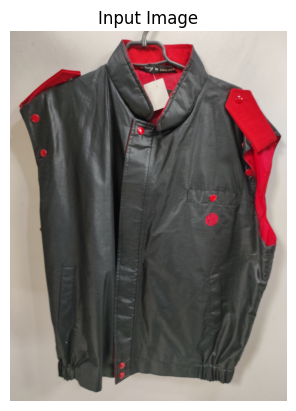

In [61]:
# Show image
import matplotlib.pyplot as plt

img = image.load_img(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Input Image")
plt.show()

In [62]:
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print("Predicted class index:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class index: 5


In [63]:
predicted_label = le.inverse_transform([predicted_class])
print("Predicted label:", predicted_label[0])

Predicted label: Outwear
